In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, matthews_corrcoef
import os
import numpy as np
import seaborn as sns
import numpy as np
from scipy.stats import rankdata, friedmanchisquare, f

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
MT_METRICS = ["g_mean", "recall", "precision", "f1-score", "mcc"] # Evaluation metrics for the meta-model
CLF_METRICS = ["kappa"] #, "precision", "recall", "f1-score"]
CLF_MODELS = ["RandomForestClassifier"] #, "DecisionTreeClassifier", "LogisticRegression", "SVC"]

REG_METRICS = ["r2"] # , "mse", "std"]
REG_MODELS = ["RandomForestRegressor"] #, "DecisionTreeRegressor"]

DATASETS = [file for file in os.listdir("../../datasets/synthetic/") if "csv" in file]
REG_DATASETS = ["gradual_friedman.csv"]
CLF_DATASETS = list(set(DATASETS).difference(set(REG_DATASETS)))

In [3]:
def get_concept(original_idx: pd.Series, dataset: str, concept_type="last"):
    """Read the original dataframe to recover the context

    Args:
        original_idx (pd.Series): maps the metabase indexes to the original base indexes (before windowing)
        dataset (str): dataset name to be loaded
        concept_type (str, optional): how to set the window concept, it can be:
            - "last": The last concept of the batch
            - "most_frequent": The most frequent concept of the batch
    """
    filename_concept = f'../../datasets/synthetic/{dataset}'
    df_concept = pd.read_csv(filename_concept)['concept']

    concepts = []
    for idx in original_idx:
        bounds = [int(bound) for bound in idx.split(':')]
        concept_batch = df_concept[bounds[0]:bounds[1]]
        
        if concept_type == "last":
            concepts.append(concept_batch.values[-1])
        else:
            most_frequent_concept = concept_batch.value_counts().idxmax()
            concepts.append(most_frequent_concept)
    return concepts

def load_data(dataset, model, concept_type="last"):
    filename_mtl = f'../metabases/basemodel: {model} - dataset: {dataset} - with_drift_metrics.csv'
    results = pd.read_csv(filename_mtl)
    concept = get_concept(results['original_idx'], dataset, concept_type)
    results['concept'] = concept
    return results

In [4]:
def remove_unused_cols(df: pd.DataFrame) -> pd.DataFrame:
    metrics = CLF_METRICS if "kappa" in df.columns else REG_METRICS
    cols_to_keep = [
        "concept",  # concept
        *metrics,  # target cols
        *[f"last_{col}" for col in metrics],  # baseline cols
        *[col for col in df.columns if "drift" in col],  # drift metrics cols
        *[col for col in df.columns if "predicted" in col],  # mtl cols
    ]
    return df[cols_to_keep]

def gen_drift_alerts(dataset: str, model: str, metric: str) -> pd.DataFrame:
    df = load_data(dataset, model)
    offline_df = df[df["data_type"] == "offline"]
    online_df = df[df["data_type"] == "online"]
    online_df = remove_unused_cols(online_df)

    expected_mean, expected_std = offline_df[metric].mean(), offline_df[metric].std()

    for sensitivity in [0.5, 1, 1.5, 2]:
        threshold = expected_mean - expected_std * sensitivity
        online_df[f"mtl_alert_{metric}_s={sensitivity}"] = (online_df[f"predicted_{metric}"] <= threshold).astype(int)
    online_df["target_alert"] = (online_df["concept"] > 0).astype(int)
    # online_df["real_alert"] = (online_df[metric] <= threshold).astype(int)
    return online_df

In [5]:
# Partial test code
results = {}

for dataset in DATASETS:
    try:
        metric = "kappa" if dataset in CLF_DATASETS else "r2"
        model = "RandomForestClassifier" if dataset in CLF_DATASETS else "RandomForestRegressor"
        results[dataset] = gen_drift_alerts(dataset, model, metric)
    except:
        print(dataset)

# Drift label comparison

In [6]:
def get_perf_metrics(df: pd.DataFrame, dataset: str, target_col="target_alert") -> list:
    alert_cols = [c for c in df.columns if ("_drift_" in c or "_alert" in c)]
    results = []

    for col in alert_cols:
        sensitivity = col.split("s=")[1] if "s=" in col else None
        alert_type = "drift_metrics" if "_drift_" in col else col.split("_")[0]

        cm = confusion_matrix(df[target_col], df[col], labels=[0, 1]).ravel()
        tn, fp, fn, tp = cm  # was already implicitly destructured

        # Sensitivity (recall of the positive class) and specificity
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        recall      = tp / (tp + fn) if (tp + fn) > 0 else 0
        g_mean      = np.sqrt(recall * specificity)  # <-- G-Mean
        mcc         = matthews_corrcoef(df[target_col], df[col])  # <-- MCC

        results.append({
            'dataset':          dataset.replace('.csv', ''),
            'alert_col':        col,
            'type':             alert_type,
            'sensitivity':      sensitivity,
            'True Negatives':   cm[0],
            'False Positives':  cm[1],
            'False Negatives':  cm[2],
            'True Positives':   cm[3],
            'accuracy':         accuracy_score(df[target_col], df[col]),
            'g_mean':           g_mean,
            'mcc':              mcc,
            **classification_report(df[target_col], df[col], labels=[0, 1], output_dict=True)['1']
        })
    return results

In [7]:
# Partial test code
final_performances = []
for dataset, df in results.items():
    df = results[dataset]
    final_performances = [*final_performances, *get_perf_metrics(df, dataset)]
final_performances_df = pd.DataFrame(final_performances)

In [8]:
def get_performances(base_model_name: str) -> pd.DataFrame:
    """
    Runs the complete drift detector evaluation pipeline for a specific
    base classifier or regressor.

    The task type (classification or regression) and the target metric are
    inferred automatically from the model name suffix:
      - "...Classifier" → classification datasets, metric "kappa"
      - "...Regressor"  → regression datasets,    metric "r2"

    Args:
        base_model_name (str): Name of the base model used to generate the
            metabases. Examples: "RandomForestClassifier", "DecisionTreeRegressor".

    Returns:
        pd.DataFrame: DataFrame equivalent to `final_performances_df` from the
            notebook, containing performance metrics (accuracy, precision, recall,
            f1-score, confusion matrix) for each drift detector across all datasets.

    Raises:
        ValueError: If the model name suffix is neither "Classifier" nor "Regressor".
        RuntimeError: If no dataset was successfully processed.
    """
    # --- Infer task type and target metric ---
    if base_model_name in ["RandomForestClassifier", "DecisionTreeClassifier", "LogisticRegression", "SVC"]:
        datasets = CLF_DATASETS
        metric   = "kappa"
    elif base_model_name.endswith("Regressor"):
        datasets = REG_DATASETS
        metric   = "r2"
    else:
        raise ValueError(
            f"Could not infer task type from '{base_model_name}'. "
            "The name must end with 'Classifier' or 'Regressor'."
        )

    # --- Generate drift alerts per dataset ---
    results = {}
    for dataset in datasets:
        try:
            results[dataset] = gen_drift_alerts(dataset, base_model_name, metric)
        except Exception as e:
            print(f"[WARNING] Failed to process '{dataset}': {e}")

    if not results:
        raise RuntimeError(
            f"No dataset was successfully processed for model '{base_model_name}'."
        )

    # --- Consolidate performance metrics ---
    final_performances = []
    for dataset, df in results.items():
        final_performances.extend(get_perf_metrics(df, dataset))

    return pd.DataFrame(final_performances)

In [9]:
ordered_df = final_performances_df.sort_values(by=['dataset','alert_col'])
ordered_df.head(10)

,dataset,alert_col,type,sensitivity,True Negatives,False Positives,False Negatives,True Positives,accuracy,g_mean,mcc,precision,recall,f1-score,support
132,abrupt_mixed_balanced,dc_drift_flag,drift_metrics,None,1,282,0,107,0.276923,0.059444,0.031176,0.275064,1.000000,0.431452,107.0
133,abrupt_mixed_balanced,mtl_alert_kappa_s=0.5,mtl,0.5,247,36,0,107,0.907692,0.934233,0.808126,0.748252,1.000000,0.856000,107.0
134,abrupt_mixed_balanced,mtl_alert_kappa_s=1,mtl,1,257,26,0,107,0.933333,0.952957,0.854751,0.804511,1.000000,0.891667,107.0
135,abrupt_mixed_balanced,mtl_alert_kappa_s=1.5,mtl,1.5,258,25,0,107,0.935897,0.954809,0.859650,0.810606,1.000000,0.895397,107.0
136,abrupt_mixed_balanced,mtl_alert_kappa_s=2,mtl,2,260,23,0,107,0.941026,0.958503,0.869588,0.823077,1.000000,0.902954,107.0
130,abrupt_mixed_balanced,omv_pth_drift_flag,drift_metrics,None,283,0,107,0,0.725641,0.000000,0.000000,0.000000,0.000000,0.000000,107.0
128,abrupt_mixed_balanced,psi_drift_flag,drift_metrics,None,255,28,95,12,0.684615,0.317889,0.019427,0.300000,0.112150,0.163265,107.0
131,abrupt_mixed_balanced,sqsi_drift_flag,drift_metrics,None,283,0,107,0,0.725641,0.000000,0.000000,0.000000,0.000000,0.000000,107.0
137,abrupt_mixed_balanced,target_alert,target,None,283,0,0,107,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,107.0
129,abrupt_mixed_balanced,u_detect_drift_flag,drift_metrics,None,277,6,104,3,0.717949,0.165659,0.020314,0.333333,0.028037,0.051724,107.0


In [10]:
# Partial test code to verify if the method 'get_performances' is working.
final_performances_df = get_performances("SVC")
ordered_df = final_performances_df.sort_values(by=['dataset','alert_col'])
ordered_df.head(10)

,dataset,alert_col,type,sensitivity,True Negatives,False Positives,False Negatives,True Positives,accuracy,g_mean,mcc,precision,recall,f1-score,support
164,abrupt_mixed_balanced,dc_drift_flag,drift_metrics,None,1,282,0,107,0.276923,0.059444,0.031176,0.275064,1.000000,0.431452,107.0
165,abrupt_mixed_balanced,mtl_alert_kappa_s=0.5,mtl,0.5,211,72,0,107,0.815385,0.863472,0.667595,0.597765,1.000000,0.748252,107.0
166,abrupt_mixed_balanced,mtl_alert_kappa_s=1,mtl,1,242,41,0,107,0.894872,0.924729,0.786277,0.722973,1.000000,0.839216,107.0
167,abrupt_mixed_balanced,mtl_alert_kappa_s=1.5,mtl,1.5,259,24,0,107,0.938462,0.956658,0.864595,0.816794,1.000000,0.899160,107.0
168,abrupt_mixed_balanced,mtl_alert_kappa_s=2,mtl,2,260,23,0,107,0.941026,0.958503,0.869588,0.823077,1.000000,0.902954,107.0
161,abrupt_mixed_balanced,omv_pth_drift_flag,drift_metrics,None,283,0,107,0,0.725641,0.000000,0.000000,0.000000,0.000000,0.000000,107.0
162,abrupt_mixed_balanced,psi_drift_flag,drift_metrics,None,256,27,94,13,0.689744,0.331518,0.038369,0.325000,0.121495,0.176871,107.0
163,abrupt_mixed_balanced,sqsi_drift_flag,drift_metrics,None,283,0,107,0,0.725641,0.000000,0.000000,0.000000,0.000000,0.000000,107.0
169,abrupt_mixed_balanced,target_alert,target,None,283,0,0,107,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,107.0
160,abrupt_mixed_balanced,u_detect_drift_flag,drift_metrics,None,283,0,107,0,0.725641,0.000000,0.000000,0.000000,0.000000,0.000000,107.0


# DataFrame formating

## Functions & dictionaries

In [11]:
# Renaming dataset names to reduce length and align with the BRACIS'26 paper
dataset_rename = {
    "gradual_agrawal_balanced_with_noise": "P01",
    "gradual_agrawal_balanced": "P02",
    "gradual_agrawal_unbalanced_with_noise": "P03",
    "gradual_agrawal_unbalanced": "P04",
    "abrupt_recurring_mixed_balanced": "P05",
    "abrupt_mixed_balanced": "P06",
    "abrupt_mixed_unbalanced": "P07",
    "abrupt_recurring_sea": "P08",
    "abrupt_sea_noise": "P09",
    "abrupt_sea": "P10",
    "abrupt_recurring_sine_balanced": "P11",
    "abrupt_sine_unbalanced": "P12",
    "abrupt_sine_unbalanced_noise": "P13",
    "abrupt_sine_balanced": "P14",
    "abrupt_sine_balanced_noise": "P15",
    "abrupt_recurring_stagger_balanced": "P16",
    "abrupt_stagger_balanced": "P17",
    "abrupt_stagger_unbalanced": "P18",
}
    
# Renaming 'drift alert' names to reduce length and align with the BRACIS'26 paper
alert_col_rename = {
    'psi_drift_flag': 'PSI',
    'u_detect_drift_flag': 'UDetect',
    'sqsi_drift_flag': 'SQSI-IS',
    'dc_drift_flag': 'DC',
    'mtl_alert_kappa_s=0.5': 'MetaDD (s=0.5)',
    'mtl_alert_kappa_s=1': 'MetaDD (s=1.0)',
    'mtl_alert_kappa_s=2': 'MetaDD (s=2.0)',
}

# Groups of problems (data stream) by drift type
groups = {
    "Gradual":   ["P01", "P02", "P03", "P04"],
    "Abrupt":    ["P06", "P07", "P09", "P10", "P12", "P13", "P14", "P15", "P17", "P18"],
    "Recurring": ["P05", "P08", "P11", "P16"],
}

In [12]:
friedman_test_cols = list(alert_col_rename.keys())
friedman_test_cols

['psi_drift_flag',
 'u_detect_drift_flag',
 'sqsi_drift_flag',
 'dc_drift_flag',
 'mtl_alert_kappa_s=0.5',
 'mtl_alert_kappa_s=1',
 'mtl_alert_kappa_s=2']

In [13]:
friedman_test_rows = list(dataset_rename.keys())
friedman_test_rows

['gradual_agrawal_balanced_with_noise',
 'gradual_agrawal_balanced',
 'gradual_agrawal_unbalanced_with_noise',
 'gradual_agrawal_unbalanced',
 'abrupt_recurring_mixed_balanced',
 'abrupt_mixed_balanced',
 'abrupt_mixed_unbalanced',
 'abrupt_recurring_sea',
 'abrupt_sea_noise',
 'abrupt_sea',
 'abrupt_recurring_sine_balanced',
 'abrupt_sine_unbalanced',
 'abrupt_sine_unbalanced_noise',
 'abrupt_sine_balanced',
 'abrupt_sine_balanced_noise',
 'abrupt_recurring_stagger_balanced',
 'abrupt_stagger_balanced',
 'abrupt_stagger_unbalanced']

In [14]:
# Filters and renames some DataFrame columns for display in diagrams (e.g., heatmap).
def col_filter(raw_df: pd.DataFrame):
    # Filtering values that are not relevant to the BRACIS'26 paper
    df = raw_df[raw_df["dataset"] != "gradual_friedman"]
    df = df[~df["alert_col"].isin(["target_alert", "mtl_alert_kappa_s=1.5", "omv_pth_drift_flag"])]
    df = df[~df["dataset"].isin(["gradual_agrawal_balanced_increasing_noise", "gradual_agrawal_unbalanced_increasing_noise"])]
    return df

In [15]:
filtered = col_filter(final_performances_df)
filtered

,dataset,alert_col,type,sensitivity,True Negatives,False Positives,False Negatives,True Positives,accuracy,g_mean,mcc,precision,recall,f1-score,support
0,abrupt_recurring_sine_balanced,psi_drift_flag,drift_metrics,None,0,283,0,107,0.274359,0.000000,0.000000,0.274359,1.000000,0.430584,107.0
1,abrupt_recurring_sine_balanced,u_detect_drift_flag,drift_metrics,None,159,124,61,46,0.525641,0.491465,-0.007429,0.270588,0.429907,0.332130,107.0
3,abrupt_recurring_sine_balanced,sqsi_drift_flag,drift_metrics,None,283,0,107,0,0.725641,0.000000,0.000000,0.000000,0.000000,0.000000,107.0
4,abrupt_recurring_sine_balanced,dc_drift_flag,drift_metrics,None,0,283,0,107,0.274359,0.000000,0.000000,0.274359,1.000000,0.430584,107.0
5,abrupt_recurring_sine_balanced,mtl_alert_kappa_s=0.5,mtl,0.5,157,126,10,97,0.651282,0.709170,0.415977,0.434978,0.906542,0.587879,107.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183,abrupt_recurring_sea,sqsi_drift_flag,drift_metrics,None,283,0,140,0,0.669031,0.000000,0.000000,0.000000,0.000000,0.000000,140.0
184,abrupt_recurring_sea,dc_drift_flag,drift_metrics,None,0,283,0,140,0.330969,0.000000,0.000000,0.330969,1.000000,0.497336,140.0
185,abrupt_recurring_sea,mtl_alert_kappa_s=0.5,mtl,0.5,205,78,18,122,0.773050,0.794510,0.561562,0.610000,0.871429,0.717647,140.0
186,abrupt_recurring_sea,mtl_alert_kappa_s=1,mtl,1,239,44,24,116,0.839243,0.836509,0.653124,0.725000,0.828571,0.773333,140.0


In [16]:
def prepare_results(df: pd.DataFrame) -> pd.DataFrame:
    """Filters and renames datasets and alert columns for display."""
    df = col_filter(df)
    df["dataset"]   = df["dataset"].replace(dataset_rename)
    df["alert_col"] = df["alert_col"].replace(alert_col_rename)
    return df

In [17]:
prepared_df = prepare_results(filtered)
prepared_df

,dataset,alert_col,type,sensitivity,True Negatives,False Positives,False Negatives,True Positives,accuracy,g_mean,mcc,precision,recall,f1-score,support
0,P11,PSI,drift_metrics,None,0,283,0,107,0.274359,0.000000,0.000000,0.274359,1.000000,0.430584,107.0
1,P11,UDetect,drift_metrics,None,159,124,61,46,0.525641,0.491465,-0.007429,0.270588,0.429907,0.332130,107.0
3,P11,SQSI-IS,drift_metrics,None,283,0,107,0,0.725641,0.000000,0.000000,0.000000,0.000000,0.000000,107.0
4,P11,DC,drift_metrics,None,0,283,0,107,0.274359,0.000000,0.000000,0.274359,1.000000,0.430584,107.0
5,P11,MetaDD (s=0.5),mtl,0.5,157,126,10,97,0.651282,0.709170,0.415977,0.434978,0.906542,0.587879,107.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
183,P08,SQSI-IS,drift_metrics,None,283,0,140,0,0.669031,0.000000,0.000000,0.000000,0.000000,0.000000,140.0
184,P08,DC,drift_metrics,None,0,283,0,140,0.330969,0.000000,0.000000,0.330969,1.000000,0.497336,140.0
185,P08,MetaDD (s=0.5),mtl,0.5,205,78,18,122,0.773050,0.794510,0.561562,0.610000,0.871429,0.717647,140.0
186,P08,MetaDD (s=1.0),mtl,1,239,44,24,116,0.839243,0.836509,0.653124,0.725000,0.828571,0.773333,140.0


In [18]:
def clean_dataframe(df: pd.DataFrame, metric=None):
    if not metric in MT_METRICS:
        raise ValueError(
            f"No metric was informed to be isolated '{metric}'."
        )
        
    # rows = datasets, columns = algorithms
    data_dic = {}
    for row_value in dataset_rename.values():
        #print(row)
        row = []
        for col_value in alert_col_rename.values():
            filtered = df.loc[
                (df["dataset"] == row_value) &
                (df["alert_col"] == col_value),
                metric
                ].iloc[0].item()
            row.append(filtered)
    
        data_dic[row_value] = row

    tmp_df = pd.DataFrame.from_dict(data_dic, orient='index', columns=['PSI', 'UDetect', 'SQSI-IS', 'DC', 'MetaDD (s=0.5)', 'MetaDD (s=1.0)', 'MetaDD (s=2.0)'])
    
    return tmp_df
    

## Dataframe exploration

In [19]:
rows_names = final_performances_df["dataset"].unique().tolist()

# Remove values not considered in the BRACIS paper
rows_names.remove('gradual_agrawal_balanced_increasing_noise')
rows_names.remove('gradual_agrawal_unbalanced_increasing_noise')

print("Detectors:", len(rows_names))
rows_names

Detectors: 18


['abrupt_recurring_sine_balanced',
 'abrupt_sea',
 'gradual_agrawal_unbalanced_with_noise',
 'gradual_agrawal_balanced',
 'abrupt_sine_unbalanced',
 'abrupt_stagger_unbalanced',
 'gradual_agrawal_balanced_with_noise',
 'abrupt_mixed_unbalanced',
 'abrupt_stagger_balanced',
 'abrupt_sine_balanced_noise',
 'abrupt_sine_unbalanced_noise',
 'abrupt_recurring_stagger_balanced',
 'abrupt_sine_balanced',
 'abrupt_sea_noise',
 'abrupt_recurring_mixed_balanced',
 'abrupt_mixed_balanced',
 'gradual_agrawal_unbalanced',
 'abrupt_recurring_sea']

In [20]:
cols_names = final_performances_df["alert_col"].unique().tolist()

# Remove valores que não foram considerados no artigo para o BRACIS
cols_names.remove('mtl_alert_kappa_s=1.5')
cols_names.remove('omv_pth_drift_flag')
cols_names.remove('target_alert')

print("Detectors:", len(cols_names))
cols_names

Detectors: 7


['psi_drift_flag',
 'u_detect_drift_flag',
 'sqsi_drift_flag',
 'dc_drift_flag',
 'mtl_alert_kappa_s=0.5',
 'mtl_alert_kappa_s=1',
 'mtl_alert_kappa_s=2']

# Display functions

In [21]:
def heatmap(df: pd.DataFrame, cell_width=1.5, cell_height=0.5, xlabel:str="", ylabel:str="", kws_label:str="", save_pdf:str=None):
    """
    Renders a styled heatmap from a DataFrame.

    Each cell displays its value formatted to 2 decimal places.
    Figure size scales automatically with the number of rows and columns.

    Args:
        df         (pd.DataFrame): Data to visualize.
        cell_width  (float): Width in inches per column. Default 1.5.
        cell_height (float): Height in inches per row. Default 0.5.
        xlabel      (str): Label for the x-axis. Default "".
        ylabel      (str): Label for the y-axis. Default "".
        kws_label   (str): Label for the colorbar. Default "".
        save_pdf    (str): File path to save the figure as PDF. If None, no file is saved. Default None.
    """
    # Infer figure dimensions from the DataFrame shape
    n_cols = df.shape[1]
    n_rows = df.shape[0]
    fig, ax = plt.subplots(figsize=(n_cols * cell_width, n_rows * cell_height))

    # Draw the heatmap with annotations, Blues colormap and thin white cell borders
    sns.heatmap(
        df,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        linewidths=0.5,
        linecolor='white',
        annot_kws={'size': 9},
        cbar_kws={'shrink': 0.6, 'label': kws_label, 'pad': 0.02},
        ax=ax,
    )

    # Format tick labels: horizontal, font size 9
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0, ha='center', fontsize=9)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

    # Set axis labels
    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)

    plt.tight_layout()

    # Optionally save the figure as a PDF before displaying
    if save_pdf:
        plt.savefig(save_pdf, format="pdf", bbox_inches="tight")

    plt.show()

In [22]:
def plot_heatmap(df: pd.DataFrame, metric='f1-score', xlabel:str="", ylabel:str="", kws_label:str=""):
    """
    Plots a heatmap of drift detection performance across datasets,
    with drift detection methods as rows and datasets as columns.

    Args:
        df  (pd.DataFrame): DataFrame containing columns 'alert_col', 'dataset',
            and the target metric. Typically the output of prepare_results().
        metric       (str): Column name of the metric to plot. Defaults to 'f1-score'.
        xlabel       (str): Label for the x-axis. Default "".
        ylabel       (str): Label for the y-axis. Default "".
        kws_label    (str): Label for the colorbar. Default "".
    """
    # Pivot: datasets as columns (X-axis), alert_col as rows (Y-axis)
    pivot_df = df.pivot(index='alert_col', columns='dataset', values=metric)

    fig, ax = plt.subplots(figsize=(12, 2.5))

    if kws_label is None:
        kws_label = metric

    sns.heatmap(
        pivot_df,
        annot=True,
        fmt='.2f',
        cmap='Blues',
        linewidths=0.5,
        linecolor='white',
        annot_kws={'size': 8},
        cbar=True,
        cbar_kws={'shrink': 0.6, 'label': kws_label, 'pad': 0.01},
        ax=ax,
    )

    # X-axis: datasets rotated vertically
    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=90,
        ha='center',
        fontsize=8,
    )

    # Y-axis: alert_col horizontal, on the left
    ax.yaxis.set_label_position('left')
    ax.yaxis.tick_left()
    ax.set_yticklabels(
        ax.get_yticklabels(),
        rotation=0,
        fontsize=8,
    )

    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)

    plt.tight_layout()
    plt.show()

In [23]:
def plot_heatmap_grouped(df: pd.DataFrame, groups: dict, metric: str = 'f1-score', xlabel:str="", ylabel:str="", kws_label:str="", save_pdf: str = None):
    """
    Plots a grouped heatmap of drift detection performance across datasets.

    Args:
        df (pd.DataFrame): DataFrame containing columns 'alert_col', 'dataset', and the target metric. 
                             Typically the output of col_filter().
        groups   (dict): Required. Maps group names to lists of dataset codes.
                         Example: {"Gradual": ["P01", "P02"], "Abrupt": ["P06", "P07"]}.
        metric    (str): Column name of the metric to plot. Defaults to 'f1-score'.
        kws_label (str): Label shown on the colorbar. Defaults to metric name.
        save_pdf  (str): File path to save the figure as PDF. If None, no file is saved. Default None.

    Raises:
        TypeError: If groups is not a dictionary.
        ValueError: If groups is empty.
    """
    if not isinstance(groups, dict):
        raise TypeError(
            f"'groups' must be a dictionary, got {type(groups).__name__}."
        )
    if not groups:
        raise ValueError("'groups' must not be empty.")

    pivot_df = df.pivot(index='alert_col', columns='dataset', values=metric)
    pivot_df = pivot_df.iloc[[1,2,3,0,4,5,6]] # Order lines by indexes
    
    ordered_cols = sorted(pivot_df.columns, key=lambda x: int(x[1:]))
    pivot_df = pivot_df[ordered_cols]

    n_groups = len(groups)
    group_sizes = [len(v) for v in groups.values()]

    fig, axes = plt.subplots(
        1, n_groups,
        figsize=(sum(group_sizes) * .6, len(pivot_df) * 0.4),
        gridspec_kw={"width_ratios": group_sizes}
    )

    if kws_label is None:
        kws_label = metric

    for ax, (group_name, cols) in zip(axes, groups.items()):
        subset = pivot_df[cols]
        is_last = (group_name == list(groups.keys())[-1])

        sns.heatmap(
            subset,
            annot=True,
            fmt='.2f',
            cmap='Blues',
            linewidths=0.5,
            linecolor='white',
            annot_kws={'size': 8},
            cbar=is_last,
            cbar_kws={'shrink': 0.6, 'label': kws_label} if is_last else {},
            yticklabels=True,
            ax=ax,
            vmin=pivot_df.min().min(),
            vmax=pivot_df.max().max(),
        )

        ax.set_title(group_name, fontsize=10)
        ax.set_xlabel('')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)

        if ax != axes[0]:
            ax.set_ylabel('')
            ax.yaxis.set_visible(False)
        else:
            ax.set_ylabel(ylabel, fontsize=10)
            ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)

    plt.tight_layout()
    fig.text(0.5, -0.02, xlabel, ha='center', fontsize=10)
    if save_pdf:
        plt.savefig(save_pdf, format="pdf", bbox_inches="tight")
    plt.show()

# Friedman & Nemenyi analysis

In [24]:
def friedman_test(df: pd.DataFrame, alpha=0.05, verbose=False):
    """
    Performs the Friedman test to assess whether there are statistically
    significant differences among multiple drift detection methods.

    Args:
        df (pd.DataFrame): DataFrame where rows are methods (treatments)
            and columns are datasets (blocks). Each cell contains the
            performance score of a method on a dataset.
        alpha (float): Significance level for the hypothesis test.
            Defaults to 0.05.
        verbose (bool): If True, prints the test statistic, p-value,
            and the conclusion regarding H0. Defaults to False.

    Returns:
        bool: True if H0 is rejected (significant differences found),
            False otherwise.
    """
    stat, p_value = friedmanchisquare(*[df[col].values for col in df.columns])

    if verbose:
        print(f"Friedman Test")
        print(f"  Statistic : {stat:.4f}")
        print(f"  p-value   : {p_value:.4f}")
        print(f"  alpha     : {alpha}")
        print()

        if p_value < alpha:
            print("✅ H0 rejected: there is a significant difference among the methods.")
            return True
        else:
            print("❌ Failed to reject H0: there is no significant difference among the methods.")
            return False

In [25]:
def friedman_test_corrected(df: pd.DataFrame, alpha=0.05, verbose=False):
    """
    Performs the Friedman test with the Iman & Davenport correction,
    which converts the Friedman chi-squared statistic into an F-statistic
    for a more powerful and accurate hypothesis test.

    Args:
        df (pd.DataFrame): DataFrame where rows are methods (treatments)
            and columns are datasets (blocks). Each cell contains the
            performance score of a method on a dataset.
        alpha (float): Significance level for the hypothesis test.
            Defaults to 0.05.
        verbose (bool): If True, prints the original chi-squared statistic,
            the corrected F-statistic, degrees of freedom, p-values,
            and the conclusion regarding H0. Defaults to False.

    Returns:
        bool: True if H0 is rejected (significant differences found),
            False otherwise.
    """
    N = df.shape[1]  # number of columns (groups/problems)
    k = df.shape[0]  # number of rows (methods)

    # Original Friedman chi-squared statistic
    chi2_f, p_chi2 = friedmanchisquare(*[df[col].values for col in df.columns])

    # Iman & Davenport correction
    ff = (N - 1) * chi2_f / (N * (k - 1) - chi2_f)
    df1 = k - 1
    df2 = (k - 1) * (N - 1)
    p_ff = 1 - f.cdf(ff, df1, df2)

    if verbose:
        print(f"Friedman Test (Iman & Davenport correction)")
        print(f"  N (groups)  : {N}")
        print(f"  k (methods) : {k}")
        print(f"  χ²_F        : {chi2_f:.4f}  (p = {p_chi2:.4f})")
        print(f"  F_F         : {ff:.4f}  (p = {p_ff:.4f})  [df1={df1}, df2={df2}]")
        print(f"  alpha       : {alpha}")
        print()

        if p_ff < alpha:
            print("✅ H0 rejected: there is a significant difference among the methods.")
            return True
        else:
            print("❌ Failed to reject H0: there is no significant difference among the methods.")
            return False

In [26]:
def get_ranking(df):
    ranks = df.rank(axis=0, ascending=False).mean(axis=1)
    return ranks

In [27]:
from scipy.stats import studentized_range

def get_critical_distance(df:pd.DataFrame, ranks, alpha=0.05, verbose=False):
    k = len(ranks)       # número de detectores
    n = len(df.columns)  # número de datasets
    
    cd = studentized_range.ppf(1 - alpha, k, np.inf) / np.sqrt(2) * np.sqrt(k * (k + 1) / (6 * n))

    if verbose:
        print(f"Critical Distance (CD): {cd:.2f}")
    return cd

In [28]:
from autorank import autorank, plot_stats

def plot_cd_diagram(df:pd.DataFrame):
    result = autorank(df.T, alpha=0.05)
    plot_stats(result)

# Results

In [29]:
# Result variables
H_XLABEL_1 = "Evaluation Metrics" # Heatmap xlabel
KWS_LABEL_1 = "Score"
H_XLABEL_2 = "Problem Space" # Heatmap xlabel
KWS_LABEL_2 = "G-mean"
METRIC = "g_mean"

In [30]:
def get_avg_metrics_across_models(
    base_models: list,
    metrics: list = MT_METRICS
) -> pd.DataFrame:
    """
    For each base model, loads the performances, filters and renames them,
    then computes the average of each metric per detector (alert_col)
    across all datasets and base models.

    Args:
        base_models (list): List of base model names to evaluate.
            Examples: ["SVC", "LogisticRegression", "RandomForestClassifier"].
        metrics (list): List of metric column names to aggregate.
            Defaults to ["g_mean", "recall", "precision", "f1-score"].

    Returns:
        pd.DataFrame: DataFrame with detectors as rows and metrics as columns,
            containing the average score across all datasets and base models.
    """
    all_dfs = []
    for model in base_models:
        df = get_performances(model)
        df = prepare_results(df)
        all_dfs.append(df)

    combined = pd.concat(all_dfs, ignore_index=True)

    # Average per detector aggregating across datasets and base models
    avg_df = (
        combined
        .groupby("alert_col")[metrics]
        .mean()
    )

    return avg_df

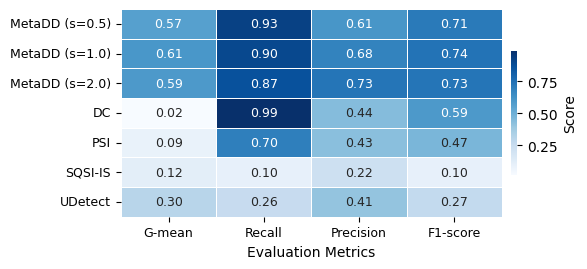

In [31]:
CLF_MODELS = ["SVC", "LogisticRegression", "DecisionTreeClassifier", "RandomForestClassifier"]

avg_df = get_avg_metrics_across_models(CLF_MODELS, ["g_mean", "recall", "precision", "f1-score"])

# Reorder by specifying the desired row order (by index labels)
avg_df = avg_df.iloc[[1,2,3,0,4,5,6]]

# Rename the columns for exhibition
avg_df.rename(columns={'g_mean': 'G-mean', 'recall': 'Recall', 'precision': 'Precision', 'f1-score': 'F1-score'}, inplace=True)

heatmap(avg_df, 1.5, .4, xlabel=H_XLABEL_1, kws_label=KWS_LABEL_1, save_pdf="heatmap.pdf")

## BaseModel: SVC

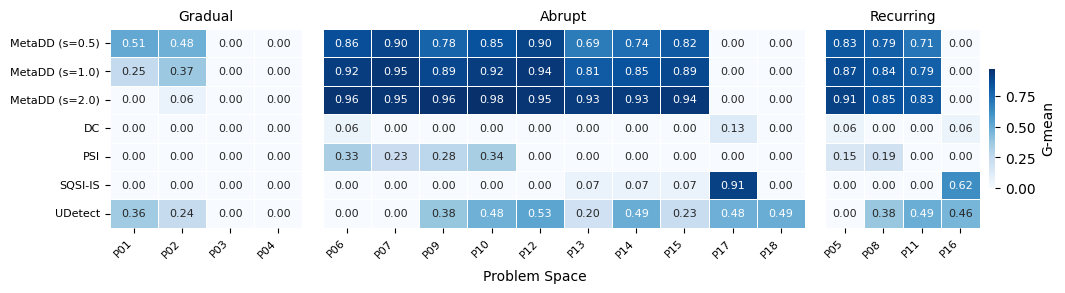

Friedman Test (Iman & Davenport correction)
  N (groups)  : 18
  k (methods) : 7
  χ²_F        : 36.9090  (p = 0.0035)
  F_F         : 8.8260  (p = 0.0000)  [df1=6, df2=102]
  alpha       : 0.05

✅ H0 rejected: there is a significant difference among the methods.
                     P01       P02  P03  P04       P05       P06       P07  \
PSI             0.000000  0.000000  0.0  0.0  0.150088  0.331518  0.227411   
UDetect         0.359950  0.242193  0.0  0.0  0.000000  0.000000  0.000000   
SQSI-IS         0.000000  0.000000  0.0  0.0  0.000000  0.000000  0.000000   
DC              0.000000  0.000000  0.0  0.0  0.059444  0.059444  0.000000   
MetaDD (s=0.5)  0.513940  0.477266  0.0  0.0  0.830460  0.863472  0.897582   
MetaDD (s=1.0)  0.249381  0.371246  0.0  0.0  0.873642  0.924729  0.945512   
MetaDD (s=2.0)  0.000000  0.064550  0.0  0.0  0.909316  0.958503  0.952957   

                     P08       P09       P10       P11       P12       P13  \
PSI             0.194964  0.27522

In [32]:
svc_df = get_performances("SVC")
svc_df = prepare_results(svc_df)
plot_heatmap_grouped(
    df = svc_df, 
    groups = groups, 
    metric = METRIC, 
    xlabel = H_XLABEL_2, 
    kws_label = KWS_LABEL_2, 
    save_pdf = 'heatmap_svc.pdf'
)

clean_svc_df = clean_dataframe(svc_df, METRIC).T
friedman_test_corrected(clean_svc_df, 0.05, True)
print(clean_svc_df)

PSI               5.19
UDetect           3.83
SQSI-IS           5.08
DC                5.39
MetaDD (s=0.5)    3.25
MetaDD (s=1.0)    2.81
MetaDD (s=2.0)    2.44
dtype: float64

Critical Distance (CD): 2.12

                meanrank    median       mad ci_lower  ci_upper effect_size  \
DC              5.388889  0.000000       0.0      0.0   0.12592         NaN   
PSI             5.194444  0.000000       0.0      0.0  0.335978         NaN   
SQSI-IS         5.083333  0.000000       0.0      0.0  0.911257         NaN   
UDetect         3.833333  0.370023  0.126284      0.0  0.526552   -2.794932   
MetaDD (s=0.5)  3.250000  0.724620  0.155907      0.0   0.90151   -4.433394   
MetaDD (s=1.0)  2.805556  0.824696  0.108553      0.0  0.945512   -7.246776   
MetaDD (s=2.0)  2.444444  0.880033   0.08031      0.0  0.975651  -10.452538   

               magnitude effect_size_above magnitude_above  
DC                 large               0.0      negligible  
PSI                large              

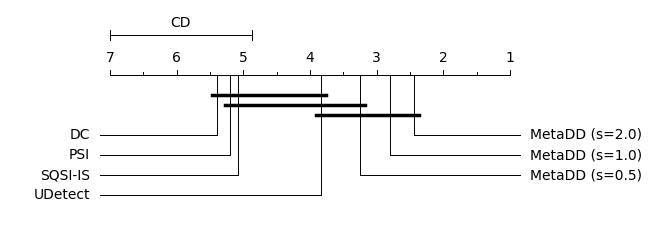

In [33]:
ranks = get_ranking(clean_svc_df)
print(ranks.round(2))
print('')
cd = get_critical_distance(clean_svc_df, ranks, verbose=True)
print('')
plot_cd_diagram(clean_svc_df)

## BaseModel: LogisticRegression

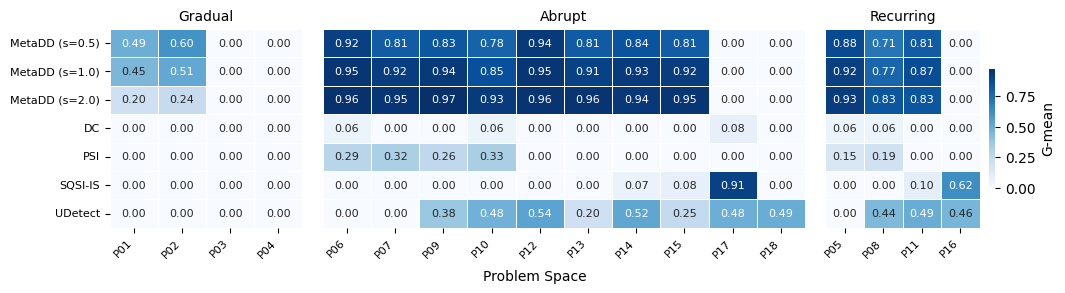

Friedman Test (Iman & Davenport correction)
  N (groups)  : 18
  k (methods) : 7
  χ²_F        : 39.4028  (p = 0.0016)
  F_F         : 9.7649  (p = 0.0000)  [df1=6, df2=102]
  alpha       : 0.05

✅ H0 rejected: there is a significant difference among the methods.
                     P01       P02  P03  P04       P05       P06       P07  \
PSI             0.000000  0.000000  0.0  0.0  0.149203  0.289051  0.324673   
UDetect         0.000000  0.000000  0.0  0.0  0.000000  0.000000  0.000000   
SQSI-IS         0.000000  0.000000  0.0  0.0  0.000000  0.000000  0.000000   
DC              0.000000  0.000000  0.0  0.0  0.059444  0.059444  0.000000   
MetaDD (s=0.5)  0.487294  0.603679  0.0  0.0  0.876419  0.915126  0.808523   
MetaDD (s=1.0)  0.446076  0.512218  0.0  0.0  0.916525  0.954809  0.922816   
MetaDD (s=2.0)  0.204124  0.241523  0.0  0.0  0.927162  0.964017  0.954809   

                     P08       P09       P10       P11       P12       P13  \
PSI             0.194576  0.26300

In [34]:
lr_df = get_performances("LogisticRegression")
lr_df = prepare_results(lr_df)
plot_heatmap_grouped(
    df = lr_df, 
    groups = groups, 
    metric = METRIC, 
    xlabel = H_XLABEL_2, 
    kws_label = KWS_LABEL_2, 
    save_pdf = 'heatmap_lr.pdf'
)

clean_lr_df = clean_dataframe(lr_df, METRIC).T
friedman_test_corrected(clean_lr_df, 0.05, True)
print(clean_lr_df)

PSI               5.14
UDetect           4.17
SQSI-IS           5.11
DC                5.42
MetaDD (s=0.5)    3.22
MetaDD (s=1.0)    2.67
MetaDD (s=2.0)    2.28
dtype: float64

Critical Distance (CD): 2.12

                meanrank    median       mad ci_lower  ci_upper effect_size  \
DC              5.416667  0.000000       0.0      0.0  0.081248         NaN   
PSI             5.138889  0.000000       0.0      0.0  0.329266         NaN   
SQSI-IS         5.111111  0.000000       0.0      0.0  0.911257         NaN   
UDetect         4.166667  0.313087  0.195926      0.0  0.536897   -1.524278   
MetaDD (s=0.5)  3.222222  0.795193  0.100741      0.0  0.936122    -7.52935   
MetaDD (s=1.0)  2.666667  0.859109  0.089873      0.0  0.954809   -9.118261   
MetaDD (s=2.0)  2.277778  0.879955  0.081304      0.0  0.974951  -10.323745   

               magnitude effect_size_above magnitude_above  
DC                 large               0.0      negligible  
PSI                large              

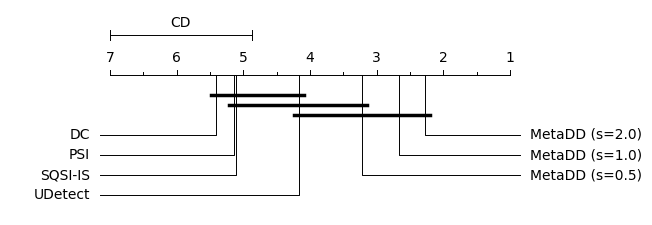

In [35]:
ranks = get_ranking(clean_lr_df)
print(ranks.round(2))
print('')
cd = get_critical_distance(clean_lr_df, ranks, verbose=True)
print('')
plot_cd_diagram(clean_lr_df)

## BaseModel: DecisionTreeClassifier

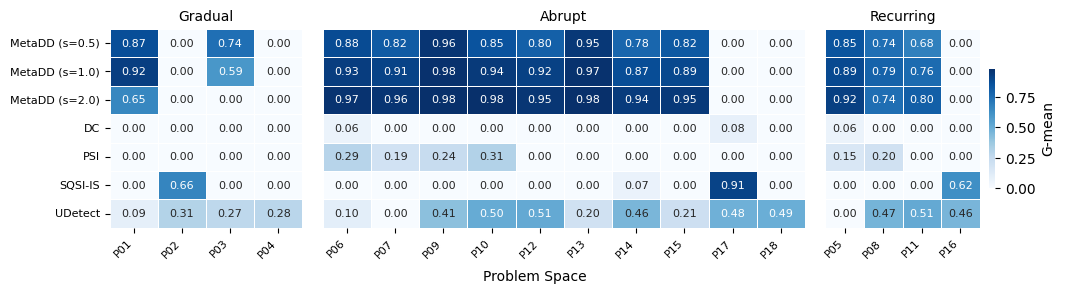

Friedman Test (Iman & Davenport correction)
  N (groups)  : 18
  k (methods) : 7
  χ²_F        : 28.9708  (p = 0.0348)
  F_F         : 6.2319  (p = 0.0000)  [df1=6, df2=102]
  alpha       : 0.05

✅ H0 rejected: there is a significant difference among the methods.
                     P01       P02       P03       P04       P05       P06  \
PSI             0.000000  0.000000  0.000000  0.000000  0.152134  0.294709   
UDetect         0.090151  0.306294  0.269690  0.279686  0.000000  0.096674   
SQSI-IS         0.000000  0.658817  0.000000  0.000000  0.000000  0.000000   
DC              0.000000  0.000000  0.000000  0.000000  0.059444  0.059444   
MetaDD (s=0.5)  0.868165  0.000000  0.742354  0.000000  0.845587  0.877678   
MetaDD (s=1.0)  0.924371  0.000000  0.593447  0.000000  0.887536  0.930443   
MetaDD (s=2.0)  0.651920  0.000000  0.000000  0.000000  0.920084  0.965848   

                     P07       P08       P09       P10       P11       P12  \
PSI             0.188504  0.19574

In [36]:
dt_df = get_performances("DecisionTreeClassifier")
dt_df = prepare_results(dt_df)
plot_heatmap_grouped(
    df = dt_df, 
    groups = groups, 
    metric = METRIC, 
    xlabel = H_XLABEL_2, 
    kws_label = KWS_LABEL_2, 
    save_pdf = 'heatmap_dt.pdf'
)

clean_dt_df = clean_dataframe(dt_df, METRIC).T
friedman_test_corrected(clean_dt_df, 0.05, True)
print(clean_dt_df)

PSI               5.19
UDetect           3.58
SQSI-IS           5.08
DC                5.58
MetaDD (s=0.5)    3.36
MetaDD (s=1.0)    2.69
MetaDD (s=2.0)    2.50
dtype: float64

Critical Distance (CD): 2.12

                meanrank    median       mad ci_lower  ci_upper effect_size  \
DC              5.583333  0.000000       0.0      0.0  0.081566         NaN   
PSI             5.194444  0.000000       0.0      0.0  0.309022         NaN   
SQSI-IS         5.083333  0.000000       0.0      0.0  0.911257         NaN   
UDetect         3.583333  0.359067  0.139017      0.0  0.510062   -2.463761   
MetaDD (s=0.5)  3.361111  0.787394  0.085527      0.0  0.958503    -8.78168   
MetaDD (s=1.0)  2.694444  0.879577  0.091675      0.0  0.976342   -9.152005   
MetaDD (s=2.0)  2.500000  0.861876  0.117379      0.0  0.980307   -7.004016   

               magnitude effect_size_above magnitude_above  
DC                 large               0.0      negligible  
PSI                large              

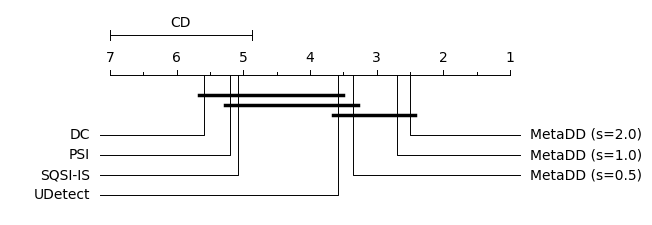

In [37]:
ranks = get_ranking(clean_dt_df)
print(ranks.round(2))
print('')
cd = get_critical_distance(clean_dt_df, ranks, verbose=True)
print('')
plot_cd_diagram(clean_dt_df)

## BaseModel: RandomForestClassifier

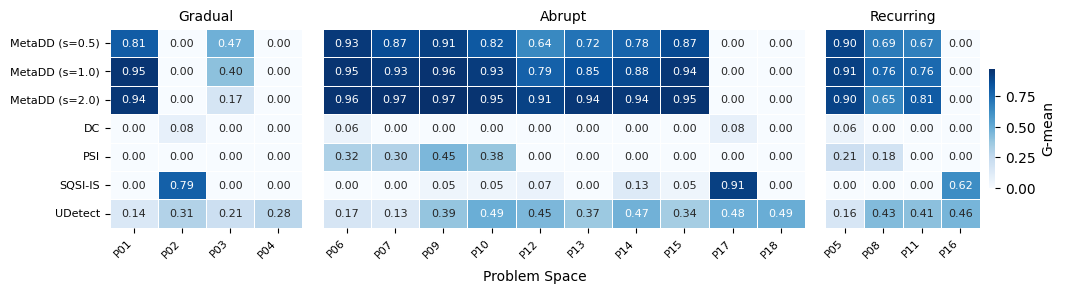

Friedman Test (Iman & Davenport correction)
  N (groups)  : 18
  k (methods) : 7
  χ²_F        : 31.6382  (p = 0.0167)
  F_F         : 7.0434  (p = 0.0000)  [df1=6, df2=102]
  alpha       : 0.05

✅ H0 rejected: there is a significant difference among the methods.
                     P01       P02       P03       P04       P05       P06  \
PSI             0.000000  0.000000  0.000000  0.000000  0.211423  0.317889   
UDetect         0.141764  0.306294  0.213433  0.279686  0.156146  0.165659   
SQSI-IS         0.000000  0.791826  0.000000  0.000000  0.000000  0.000000   
DC              0.000000  0.081216  0.000000  0.000000  0.059444  0.059444   
MetaDD (s=0.5)  0.808523  0.000000  0.474636  0.000000  0.903175  0.934233   
MetaDD (s=1.0)  0.949118  0.000000  0.402583  0.000000  0.911160  0.952957   
MetaDD (s=2.0)  0.942072  0.000000  0.170783  0.000000  0.902294  0.958503   

                     P07       P08       P09       P10       P11       P12  \
PSI             0.303758  0.18418

In [38]:
rf_df = get_performances("RandomForestClassifier")
rf_df = prepare_results(rf_df)
plot_heatmap_grouped(
    df = rf_df, 
    groups = groups, 
    metric = METRIC, 
    xlabel = H_XLABEL_2, 
    kws_label = KWS_LABEL_2, 
    save_pdf = 'heatmap_rf.pdf'
)
clean_rf_df = clean_dataframe(rf_df, METRIC).T
friedman_test_corrected(clean_rf_df, 0.05, True)
print(clean_rf_df)

PSI               5.25
UDetect           3.50
SQSI-IS           5.00
DC                5.69
MetaDD (s=0.5)    3.33
MetaDD (s=1.0)    2.67
MetaDD (s=2.0)    2.56
dtype: float64

Critical Distance (CD): 2.12

                meanrank    median       mad  ci_lower  ci_upper effect_size  \
DC              5.694444  0.000000       0.0       0.0  0.081566         NaN   
PSI             5.250000  0.000000       0.0       0.0  0.445604         NaN   
SQSI-IS         5.000000  0.000000       0.0       0.0  0.911257         NaN   
UDetect         3.500000  0.376996  0.097188  0.141764  0.493109   -3.700115   
MetaDD (s=0.5)  3.333333  0.703554  0.182828       0.0  0.934233   -3.670682   
MetaDD (s=1.0)  2.666667  0.816656  0.128786       0.0  0.959993    -6.04867   
MetaDD (s=2.0)  2.555556  0.903858  0.065888       0.0  0.971816  -13.085308   

               magnitude effect_size_above magnitude_above  
DC                 large               0.0      negligible  
PSI                large      

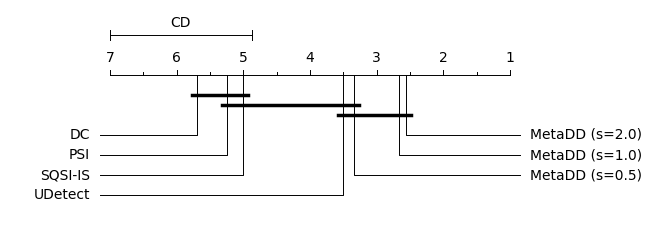

In [39]:
ranks = get_ranking(clean_rf_df)
print(ranks.round(2))
print('')
cd = get_critical_distance(clean_rf_df, ranks, verbose=True)
print('')
plot_cd_diagram(clean_rf_df)

# Feature Importance

In [40]:
import pickle

# Load: 'abrupt_sea_noise'
with open('../models/basemodel: RandomForestClassifier - dataset: abrupt_sea_noise.csv - with_drift_metrics - metric: kappa.pickle', 'rb') as f:
    my_model = pickle.load(f)

In [41]:
type(my_model)

lightgbm.sklearn.LGBMRegressor

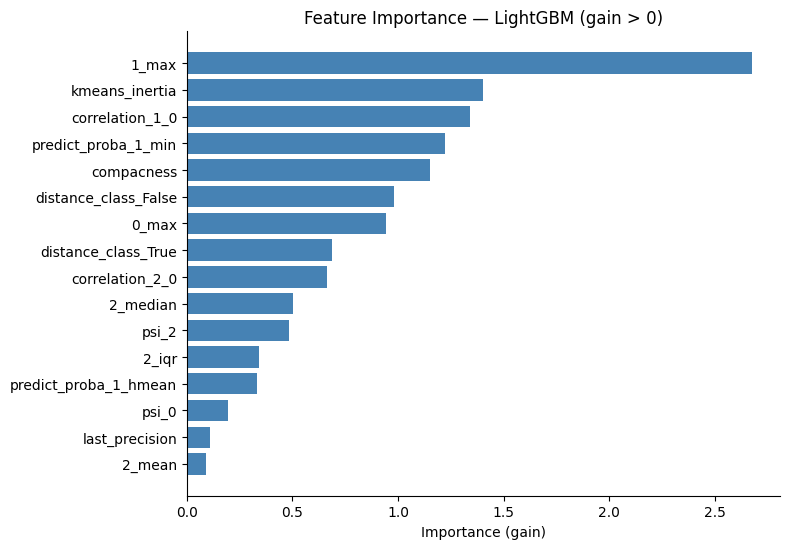

In [42]:
import lightgbm as lgb
import matplotlib.pyplot as plt
import pandas as pd


booster = my_model.booster_

# Get feature importances
importance_df = pd.DataFrame({
    'feature':    booster.feature_name(),
    'importance': booster.feature_importance(importance_type='gain')
})

# Filter only > 0 and sort
importance_df = (importance_df[importance_df['importance'] > 0]
                 .sort_values('importance', ascending=True))

# Plot
fig, ax = plt.subplots(figsize=(8, len(importance_df) * 0.35))

ax.barh(importance_df['feature'], importance_df['importance'], color='steelblue')
ax.set_xlabel('Importance (gain)')
ax.set_title('Feature Importance — LightGBM (gain > 0)')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
#plt.savefig('feature_importance.pdf', format='pdf', bbox_inches='tight')  # optional
plt.show()

## Aggregate all features from all problems (data streams: P01 to P18)

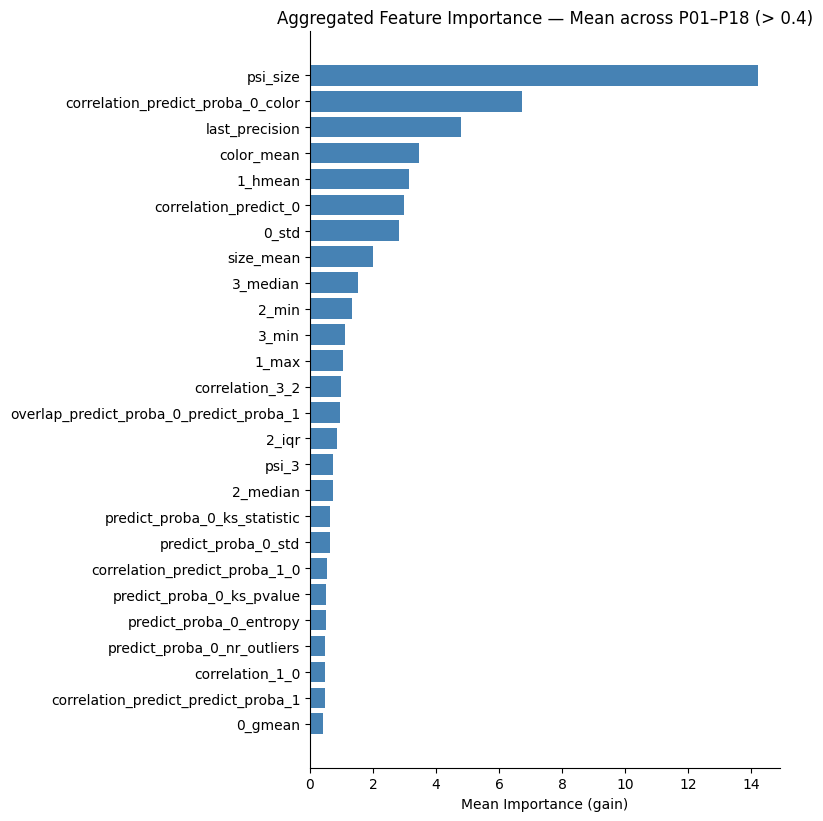

In [43]:
import os
import pickle
import pandas as pd
import matplotlib.pyplot as plt

PICKLES_DIR = "../models/"
datasets = list(dataset_rename.keys())

all_importances = []

for ds in datasets:
    path = os.path.join(PICKLES_DIR, f"basemodel: RandomForestClassifier - dataset: {ds}.csv - with_drift_metrics - metric: kappa.pickle")  # adjust filename pattern
    with open(path, 'rb') as f:
        model = pickle.load(f)

    booster = model.booster_
    imp_df = pd.DataFrame({
        'feature':    booster.feature_name(),
        'importance': booster.feature_importance(importance_type='gain'),
        'dataset':    ds
    })
    all_importances.append(imp_df)

# Concatenate all
full_df = pd.concat(all_importances, ignore_index=True)

# Aggregate: mean importance per feature across datasets
importance_threshold = 0.4
agg_df = (full_df.groupby('feature')['importance']
                 .mean()
                 .reset_index()
                 .query(f'importance > {importance_threshold}')
                 .sort_values('importance', ascending=True))

# Filter only > 0 and sort
#importance_df = (full_df[full_df['importance'] >= 1]
#                 .sort_values('importance', ascending=True))

# Plot
fig, ax = plt.subplots(figsize=(8, len(agg_df) * 0.32))

ax.barh(agg_df['feature'], agg_df['importance'], color='steelblue')
ax.set_xlabel('Mean Importance (gain)')
ax.set_title(f'Aggregated Feature Importance — Mean across P01–P18 (> {importance_threshold})')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
#plt.savefig('feature_importance.pdf', format='pdf', bbox_inches='tight')  # optional
plt.show()

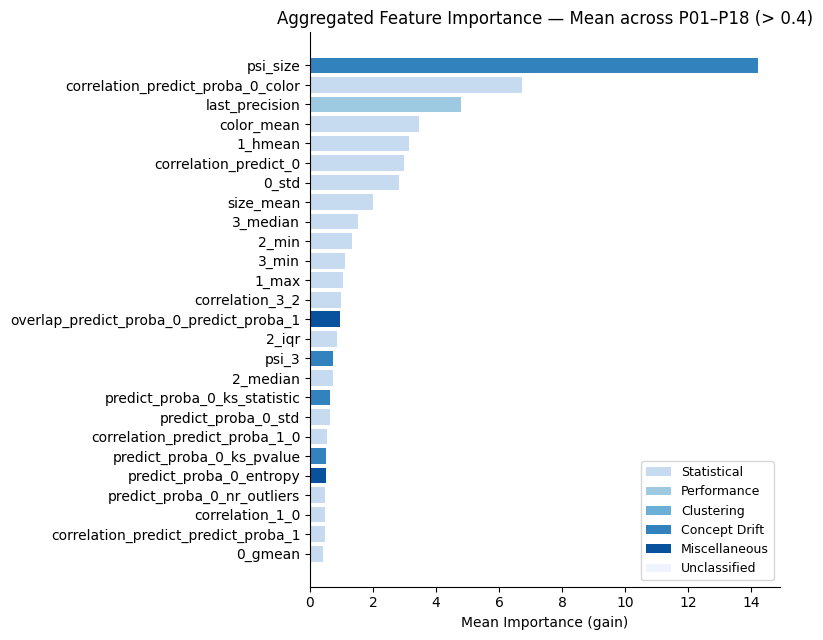

In [44]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

# Define 5 categories with blue scale (light → dark). Color palette from 'https://colorbrewer2.org/'
category_colors = {
    'Statistical':   '#c6dbef',
    'Performance':   '#9ecae1',
    'Clustering':    '#6baed6',
    'Concept Drift': '#3182bd',   
    'Miscellaneous': '#08519c',   
    'Unclassified':  '#eff3ff',
}

# Map features to categories
feature_categories = {
    '0_gmean': 'Statistical',
    'correlation_predict_predict_proba_1': 'Statistical',
    'correlation_1_0': 'Statistical',
    'predict_proba_0_nr_outliers': 'Statistical',
    'predict_proba_0_entropy': 'Miscellaneous',
    'predict_proba_0_ks_pvalue': 'Concept Drift',
    'correlation_predict_proba_1_0': 'Statistical',
    'predict_proba_0_std': 'Statistical',
    'predict_proba_0_ks_statistic': 'Concept Drift',
    '2_median': 'Statistical',
    'psi_3': 'Concept Drift',
    '2_iqr': 'Statistical',
    'overlap_predict_proba_0_predict_proba_1': 'Miscellaneous',
    'correlation_3_2': 'Statistical',
    '1_max': 'Statistical',
    '3_min': 'Statistical',
    '2_min': 'Statistical',
    '3_median': 'Statistical',
    'size_mean': 'Statistical',
    '0_std': 'Statistical',
    'correlation_predict_0': 'Statistical',
    '1_hmean': 'Statistical',
    'color_mean': 'Statistical',
    'last_precision': 'Performance',
    'correlation_predict_proba_0_color': 'Statistical',
    'psi_size': 'Concept Drift',
}

# Map colors to features in agg_df
colors = [category_colors[feature_categories.get(f, 'Unclassified')] for f in agg_df['feature']]

# Plot
fig, ax = plt.subplots(figsize=(8, len(agg_df) * 0.25))
ax.barh(agg_df['feature'], agg_df['importance'], color=colors)
ax.set_xlabel('Mean Importance (gain)')
ax.set_title(f'Aggregated Feature Importance — Mean across P01–P18 (> {importance_threshold})')
ax.spines[['top', 'right']].set_visible(False)

# Legend
legend_elements = [Patch(facecolor=c, label=cat) for cat, c in category_colors.items()]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.show()

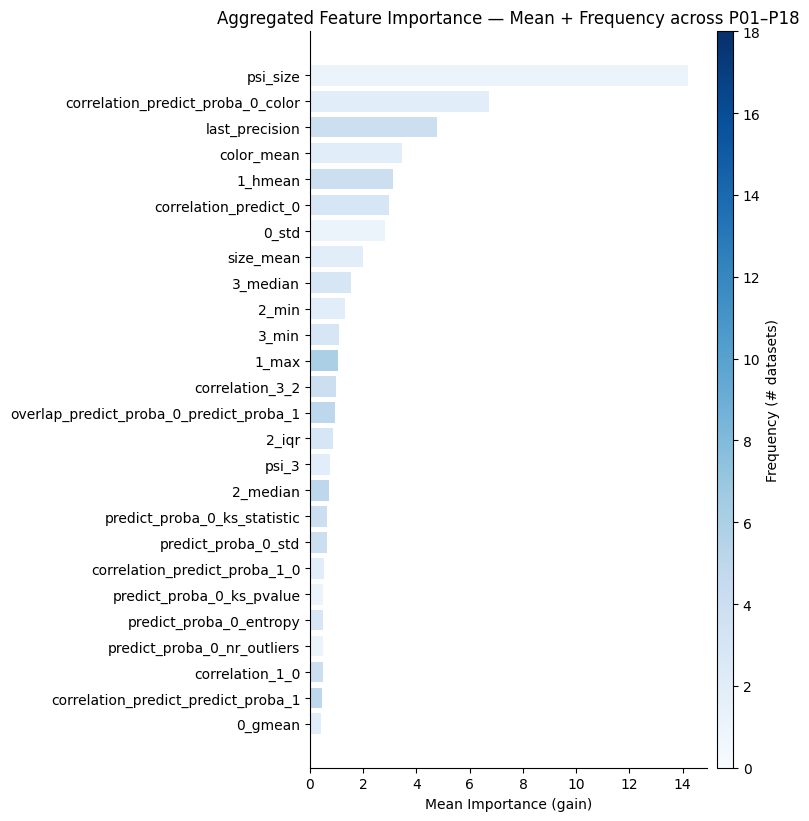

In [45]:
from mpl_toolkits.axes_grid1 import make_axes_locatable

agg_df = full_df.groupby('feature').agg(
    mean_importance=('importance', 'mean'),
    frequency=('importance', lambda x: (x > 0).sum())  # how many datasets used it
).reset_index()

agg_df = agg_df.query(f'mean_importance > {importance_threshold}').sort_values('mean_importance', ascending=True)

# Plot with frequency as color intensity
fig, ax = plt.subplots(figsize=(8, len(agg_df) * 0.32))
colors = [plt.cm.Blues(f / 18) for f in agg_df['frequency']]
bars = ax.barh(agg_df['feature'], agg_df['mean_importance'], color=colors)

sm = plt.cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(0, 18))
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="4%", pad=0.1)
plt.colorbar(sm, cax=cax, label='Frequency (# datasets)')
#plt.colorbar(sm, ax=ax, label='Frequency (# datasets)', fraction=0.4, pad=0.04)
ax.set_xlabel('Mean Importance (gain)')
ax.set_title('Aggregated Feature Importance — Mean + Frequency across P01–P18')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()